In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os
from collections import Counter
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

dataset_path = "ecg_image_data/train" 
plt.style.use('default')

In [12]:
def basic_dataset_info(dataset_path):

    print("INFORMACIÓN BÁSICA DEL DATASET")
    print("="*50)
    total_images = 0
    classes = {}
    file_extensions = []

    # Recorrer estructura del dataset
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                total_images += 1
                ext = os.path.splitext(file)[1].lower()
                file_extensions.append(ext)
                
                # Obtener clase (carpeta padre)
                class_name = os.path.basename(root)
                if class_name != os.path.basename(dataset_path):
                    classes[class_name] = classes.get(class_name, 0) + 1

    print(f"Total de imágenes: {total_images}")
    print(f"Número de clases: {len(classes)}")
    print(f"Extensiones: {set(file_extensions)}")
    print(f"Clases encontradas: {list(classes.keys())}")

    return classes, total_images



In [ ]:
def analyze_class_distribution(classes):
    print("\nDISTRIBUCIÓN DE CLASES")
    print("="*50)
    df_classes = pd.DataFrame(list(classes.items()), columns=['Clase', 'Cantidad'])
    df_classes = df_classes.sort_values('Cantidad', ascending=False)

    print(df_classes)
    print(f"\nClase más frecuente: {df_classes.iloc[0]['Clase']} ({df_classes.iloc[0]['Cantidad']} imágenes)")
    print(f"Clase menos frecuente: {df_classes.iloc[-1]['Clase']} ({df_classes.iloc[-1]['Cantidad']} imágenes)")
    print(f"Ratio desbalance: {df_classes.iloc[0]['Cantidad'] / df_classes.iloc[-1]['Cantidad']:.2f}:1")

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras
    ax1.bar(df_classes['Clase'], df_classes['Cantidad'])
    ax1.set_title('Distribución de Clases', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Clases')
    ax1.set_ylabel('Número de Imágenes')
    ax1.tick_params(axis='x', rotation=45)

    # Gráfico de pie
    ax2.pie(df_classes['Cantidad'], labels=df_classes['Clase'], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Proporción de Clases', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return df_classes



In [14]:
def analyze_image_properties(dataset_path, sample_size=1000):
    """Analizar propiedades físicas de las imágenes ECG"""
    print("\nPROPIEDADES DE LAS IMÁGENES")
    print("="*50)
    properties = {
        'width': [], 'height': [], 'channels': [], 
        'file_size_kb': [], 'aspect_ratio': [], 'class': []
    }

    # Recopilar todas las imágenes
    all_images = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_images.append(os.path.join(root, file))

    # Muestrear si hay muchas imágenes
    if len(all_images) > sample_size:
        sampled_images = np.random.choice(all_images, sample_size, replace=False)
    else:
        sampled_images = all_images

    print(f"Analizando {len(sampled_images)} imágenes...")

    # Analizar cada imagen
    for img_path in sampled_images:
        try:
            img = Image.open(img_path)
            width, height = img.size
            
            properties['width'].append(width)
            properties['height'].append(height)
            properties['channels'].append(len(img.getbands()))
            properties['file_size_kb'].append(os.path.getsize(img_path) / 1024)
            properties['aspect_ratio'].append(width / height)
            properties['class'].append(os.path.basename(os.path.dirname(img_path)))
            
        except Exception as e:
            print(f"Error procesando {img_path}: {e}")

    df_props = pd.DataFrame(properties)

    # Estadísticas descriptivas
    print("\nESTADÍSTICAS DE DIMENSIONES:")
    stats_cols = ['width', 'height', 'file_size_kb', 'aspect_ratio']
    print(df_props[stats_cols].describe().round(2))

    return df_props



In [15]:
def visualize_image_properties(df_props):
    """Visualizar propiedades de las imágenes"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Análisis de Propiedades de Imágenes ECG', fontsize=16, fontweight='bold')
    # 1. Distribución de anchos
    axes[0,0].hist(df_props['width'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title('Distribución de Anchos')
    axes[0,0].set_xlabel('Ancho (píxeles)')
    axes[0,0].set_ylabel('Frecuencia')
    axes[0,0].axvline(df_props['width'].mean(), color='red', linestyle='--', label=f'Media: {df_props["width"].mean():.0f}')
    axes[0,0].legend()

    # 2. Distribución de alturas
    axes[0,1].hist(df_props['height'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0,1].set_title('Distribución de Alturas')
    axes[0,1].set_xlabel('Altura (píxeles)')
    axes[0,1].set_ylabel('Frecuencia')
    axes[0,1].axvline(df_props['height'].mean(), color='red', linestyle='--', label=f'Media: {df_props["height"].mean():.0f}')
    axes[0,1].legend()

    # 3. Relación de aspecto
    axes[0,2].hist(df_props['aspect_ratio'], bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[0,2].set_title('Relación de Aspecto (Ancho/Alto)')
    axes[0,2].set_xlabel('Ratio')
    axes[0,2].set_ylabel('Frecuencia')
    axes[0,2].axvline(df_props['aspect_ratio'].mean(), color='red', linestyle='--', label=f'Media: {df_props["aspect_ratio"].mean():.2f}')
    axes[0,2].legend()

    # 4. Scatter: ancho vs alto
    scatter = axes[1,0].scatter(df_props['width'], df_props['height'], 
                            c=df_props['aspect_ratio'], cmap='viridis', alpha=0.6)
    axes[1,0].set_title('Ancho vs Altura')
    axes[1,0].set_xlabel('Ancho (píxeles)')
    axes[1,0].set_ylabel('Altura (píxeles)')
    plt.colorbar(scatter, ax=axes[1,0], label='Ratio')

    # 5. Tamaño de archivo
    axes[1,1].hist(df_props['file_size_kb'], bins=30, alpha=0.7, color='pink', edgecolor='black')
    axes[1,1].set_title('Tamaño de Archivos')
    axes[1,1].set_xlabel('Tamaño (KB)')
    axes[1,1].set_ylabel('Frecuencia')
    axes[1,1].axvline(df_props['file_size_kb'].mean(), color='red', linestyle='--', label=f'Media: {df_props["file_size_kb"].mean():.1f} KB')
    axes[1,1].legend()

    # 6. Canales por clase
    channel_class = df_props.groupby(['class', 'channels']).size().unstack(fill_value=0)
    channel_class.plot(kind='bar', ax=axes[1,2], stacked=True)
    axes[1,2].set_title('Canales por Clase')
    axes[1,2].set_xlabel('Clase')
    axes[1,2].set_ylabel('Número de Imágenes')
    axes[1,2].legend(title='Canales')
    axes[1,2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()




In [16]:
def analyze_ecg_quality(dataset_path, sample_size=300):
    """Analizar calidad específica para imágenes ECG"""
    print("\nANÁLISIS DE CALIDAD ECG")
    print("="*50)
    quality_metrics = {
        'brightness': [], 'contrast': [], 'sharpness': [],
        'signal_clarity': [], 'class': []
    }

    def calculate_sharpness(image):
        """Calcular nitidez usando varianza del Laplaciano"""
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        return cv2.Laplacian(gray, cv2.CV_64F).var()

    def calculate_signal_clarity(image):
        """Estimar claridad de señal ECG"""
        gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
        # Detectar bordes (representan las líneas del ECG)
        edges = cv2.Canny(gray, 50, 150)
        return np.sum(edges > 0) / edges.size  # Proporción de píxeles con bordes

    # Muestrear imágenes
    all_images = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_images.append(os.path.join(root, file))

    if len(all_images) > sample_size:
        sampled_images = np.random.choice(all_images, sample_size, replace=False)
    else:
        sampled_images = all_images

    print(f"Analizando calidad de {len(sampled_images)} imágenes...")

    for img_path in sampled_images:
        try:
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            
            # Métricas de calidad
            brightness = np.mean(img_array)
            contrast = np.std(img_array)
            sharpness = calculate_sharpness(img)
            clarity = calculate_signal_clarity(img)
            
            quality_metrics['brightness'].append(brightness)
            quality_metrics['contrast'].append(contrast)
            quality_metrics['sharpness'].append(sharpness)
            quality_metrics['signal_clarity'].append(clarity)
            quality_metrics['class'].append(os.path.basename(os.path.dirname(img_path)))
            
        except Exception as e:
            print(f"Error procesando {img_path}: {e}")

    df_quality = pd.DataFrame(quality_metrics)

    print("\nESTADÍSTICAS DE CALIDAD:")
    print(df_quality[['brightness', 'contrast', 'sharpness', 'signal_clarity']].describe().round(3))

    return df_quality



In [17]:
def visualize_quality_metrics(df_quality):
    """Visualizar métricas de calidad"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Métricas de Calidad de Imágenes ECG', fontsize=16, fontweight='bold')
    # Brillo por clase
    df_quality.boxplot(column='brightness', by='class', ax=axes[0,0])
    axes[0,0].set_title('Brillo por Clase')
    axes[0,0].set_xlabel('Clase')

    # Contraste por clase
    df_quality.boxplot(column='contrast', by='class', ax=axes[0,1])
    axes[0,1].set_title('Contraste por Clase')
    axes[0,1].set_xlabel('Clase')

    # Nitidez por clase
    df_quality.boxplot(column='sharpness', by='class', ax=axes[1,0])
    axes[1,0].set_title('Nitidez por Clase')
    axes[1,0].set_xlabel('Clase')

    # Claridad de señal por clase
    df_quality.boxplot(column='signal_clarity', by='class', ax=axes[1,1])
    axes[1,1].set_title('Claridad de Señal por Clase')
    axes[1,1].set_xlabel('Clase')

    plt.tight_layout()
    plt.show()

 

In [18]:
def detect_issues(dataset_path):
    """Detectar imágenes problemáticas"""
    print("\nDETECCIÓN DE PROBLEMAS")
    print("="*50)
    issues = {
        'corrupted': [],
        'too_small': [],
        'unusual_size': [],
        'potential_duplicates': []
    }

    image_sizes = {}
    size_counts = Counter()

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                file_path = os.path.join(root, file)
                
                try:
                    img = Image.open(file_path)
                    width, height = img.size
                    file_size = os.path.getsize(file_path)
                    
                    # Guardar dimensiones
                    size_key = f"{width}x{height}"
                    size_counts[size_key] += 1
                    
                    # Detectar problemas
                    if width < 50 or height < 50:
                        issues['too_small'].append(file_path)
                    
                    if file_size < 1000:  # Menor a 1KB
                        issues['unusual_size'].append(file_path)
                        
                except Exception as e:
                    issues['corrupted'].append(file_path)

    # Detectar tamaños poco comunes
    common_sizes = [size for size, count in size_counts.most_common(5)]

    print("TAMAÑOS MÁS COMUNES:")
    for i, (size, count) in enumerate(size_counts.most_common(10), 1):
        print(f"{i}. {size}: {count} imágenes")

    print("\nPROBLEMAS DETECTADOS:")
    for issue_type, files in issues.items():
        print(f"{issue_type}: {len(files)} archivos")
        if files and len(files) <= 3:
            for f in files[:3]:
                print(f"  - {f}")

    return issues, size_counts



In [19]:
def show_sample_images(dataset_path, samples_per_class=3):
    """Mostrar muestras de cada clase"""
    print(f"\nMUESTRAS REPRESENTATIVAS ({samples_per_class} por clase)")
    print("="*50)
    class_samples = {}

    # Recopilar muestras por clase
    for root, dirs, files in os.walk(dataset_path):
        class_name = os.path.basename(root)
        if class_name != os.path.basename(dataset_path):
            images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            
            if len(images) >= samples_per_class:
                selected = np.random.choice(images, samples_per_class, replace=False)
                class_samples[class_name] = [os.path.join(root, img) for img in selected]

    if not class_samples:
        print("No se encontraron clases con suficientes imágenes")
        return

    # Crear visualización
    n_classes = len(class_samples)
    fig, axes = plt.subplots(n_classes, samples_per_class, 
                            figsize=(samples_per_class * 4, n_classes * 3))

    if n_classes == 1:
        axes = axes.reshape(1, -1)
    elif samples_per_class == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle('Muestras por Clase', fontsize=16, fontweight='bold')

    for i, (class_name, images) in enumerate(class_samples.items()):
        for j, img_path in enumerate(images):
            try:
                img = Image.open(img_path)
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{class_name}' if j == 0 else '', fontweight='bold')
                axes[i, j].axis('off')
            except Exception as e:
                axes[i, j].text(0.5, 0.5, f'Error\n{str(e)[:20]}...', 
                            ha='center', va='center', transform=axes[i, j].transAxes)
                axes[i, j].set_title(f'{class_name}' if j == 0 else '')
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()



REPORTE COMPLETO - DATASET ECG_IMAGE_DATA
INFORMACIÓN BÁSICA DEL DATASET
Total de imágenes: 99199
Número de clases: 6
Extensiones: {'.png'}
Clases encontradas: ['N', 'S', 'F', 'M', 'V', 'Q']

DISTRIBUCIÓN DE CLASES
  Clase  Cantidad
0     N     75709
3     M      8405
5     Q      6431
4     V      5789
1     S      2223
2     F       642

Clase más frecuente: N (75709 imágenes)
Clase menos frecuente: F (642 imágenes)
Ratio desbalance: 117.93:1


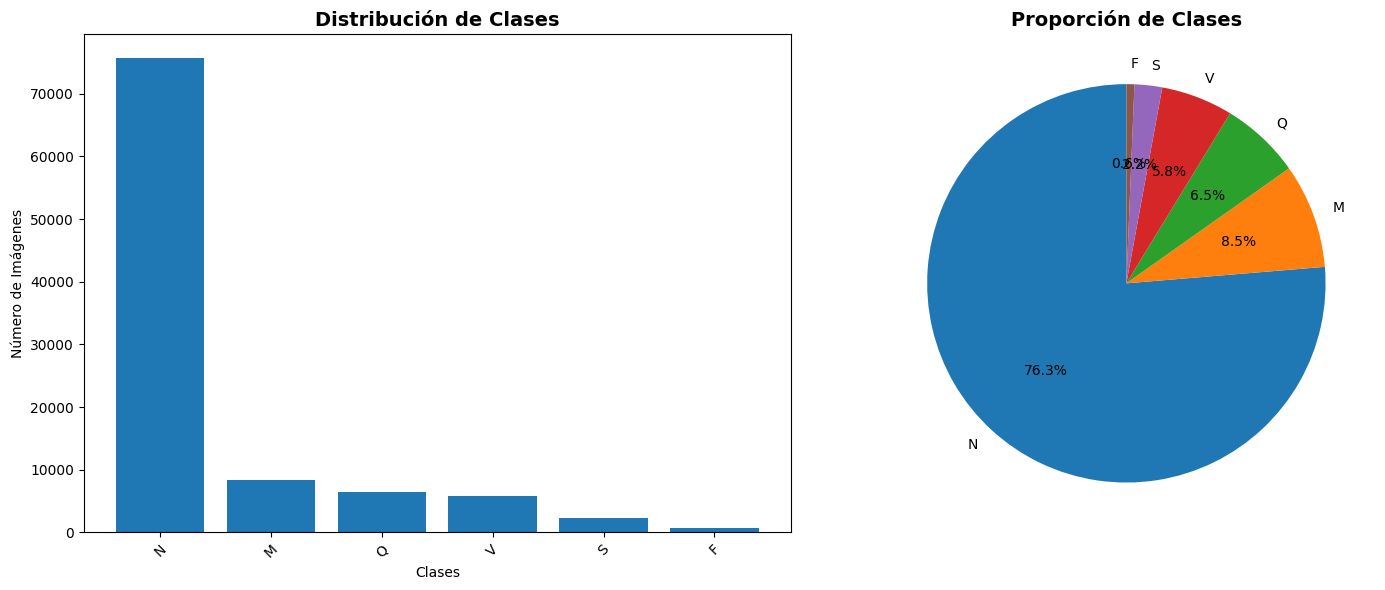


PROPIEDADES DE LAS IMÁGENES
Analizando 1000 imágenes...

ESTADÍSTICAS DE DIMENSIONES:
        width  height  file_size_kb  aspect_ratio
count  1000.0  1000.0       1000.00        1000.0
mean    432.0   288.0          7.61           1.5
std       0.0     0.0          1.11           0.0
min     432.0   288.0          3.41           1.5
25%     432.0   288.0          6.90           1.5
50%     432.0   288.0          7.47           1.5
75%     432.0   288.0          8.30           1.5
max     432.0   288.0         11.93           1.5

ANÁLISIS DE CALIDAD ECG
Analizando calidad de 300 imágenes...

ESTADÍSTICAS DE CALIDAD:
       brightness  contrast  sharpness  signal_clarity
count     300.000   300.000    300.000         300.000
mean      251.414    25.078    356.850           0.015
std         1.216     5.246    287.700           0.002
min       245.231    17.872     74.571           0.010
25%       251.342    22.185    223.324           0.014
50%       251.823    23.075    245.166      

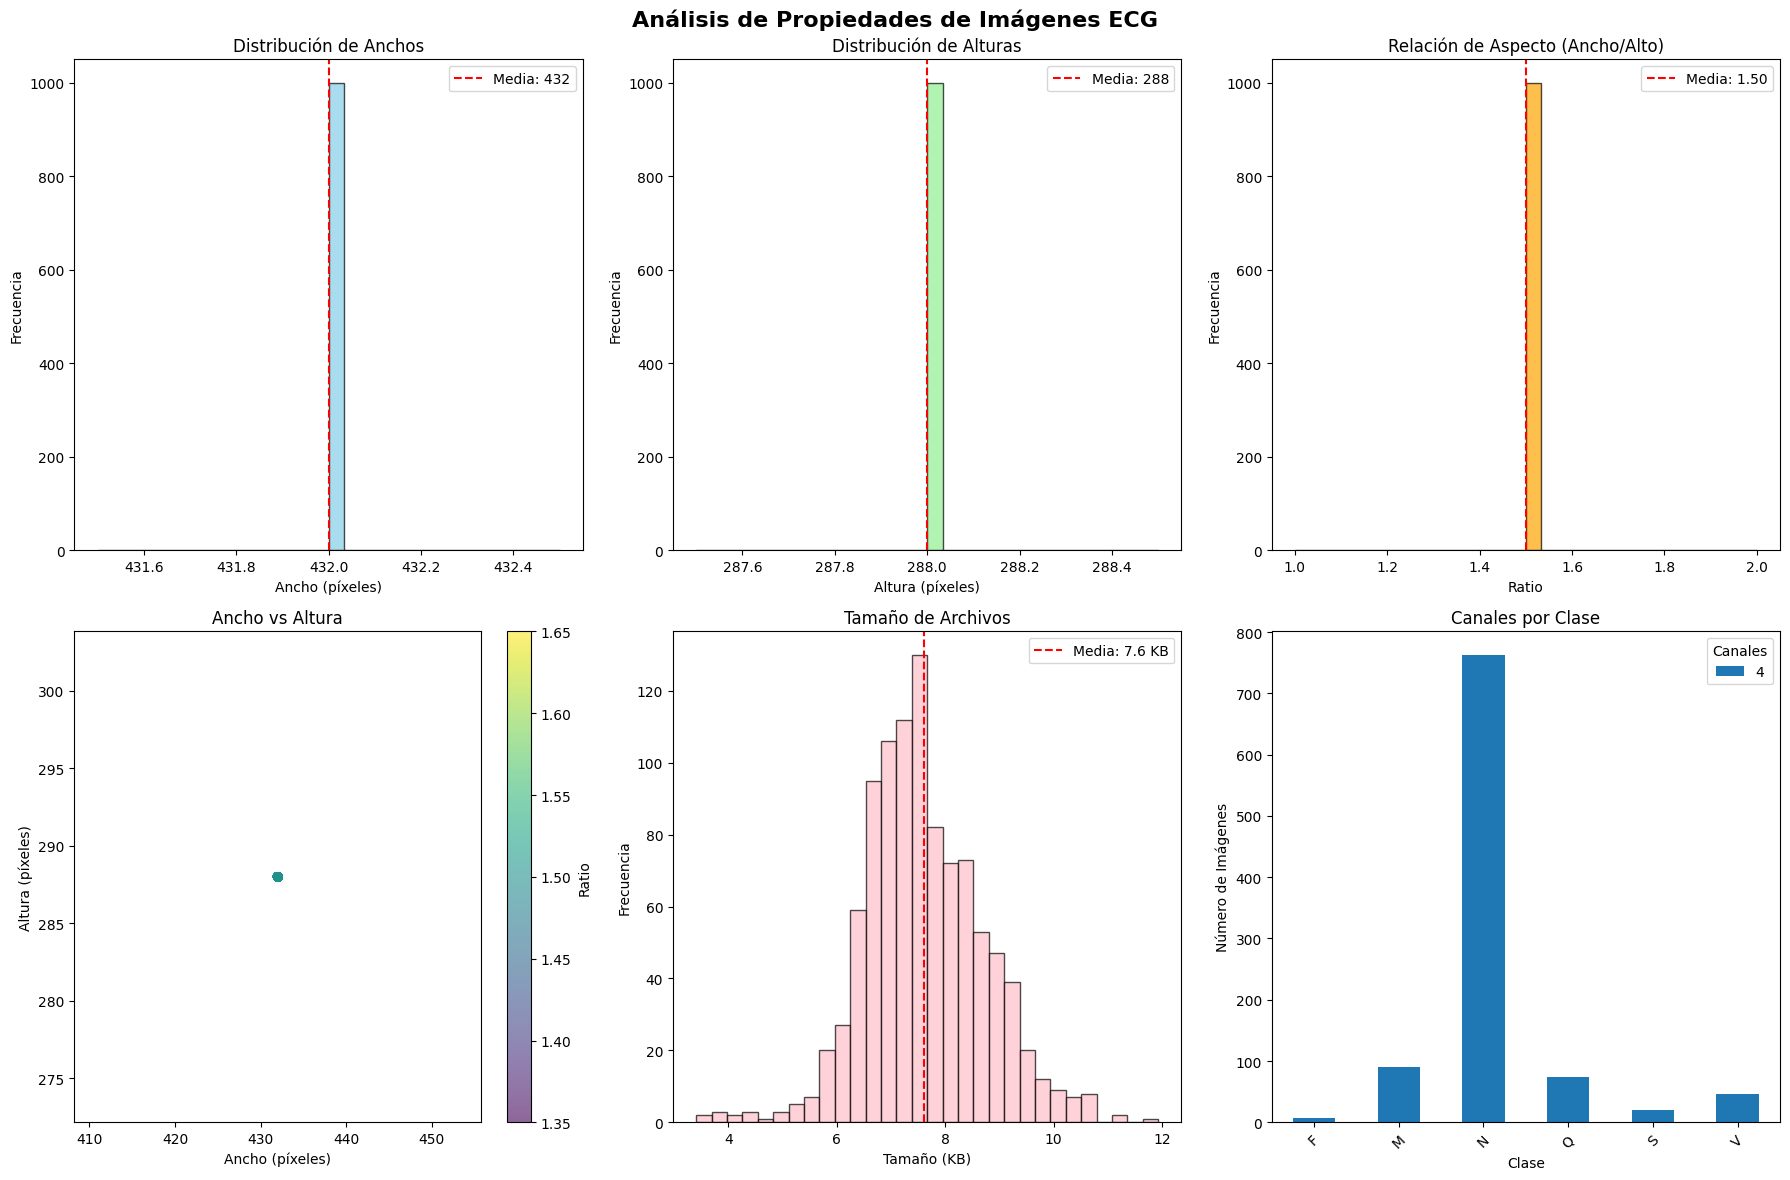

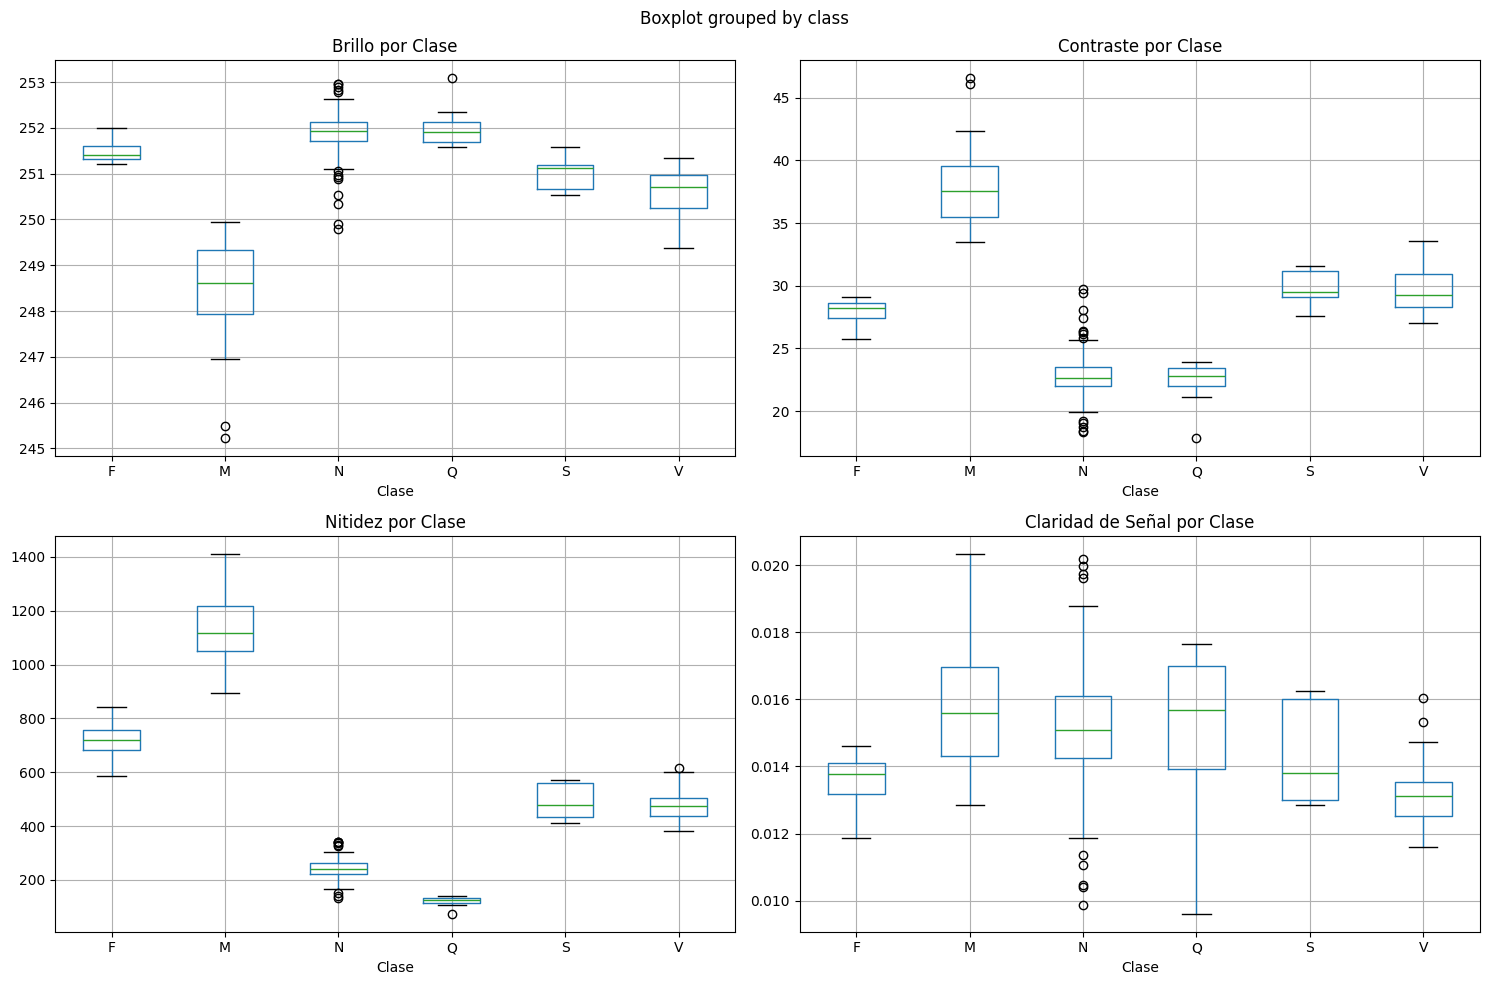


MUESTRAS REPRESENTATIVAS (3 por clase)


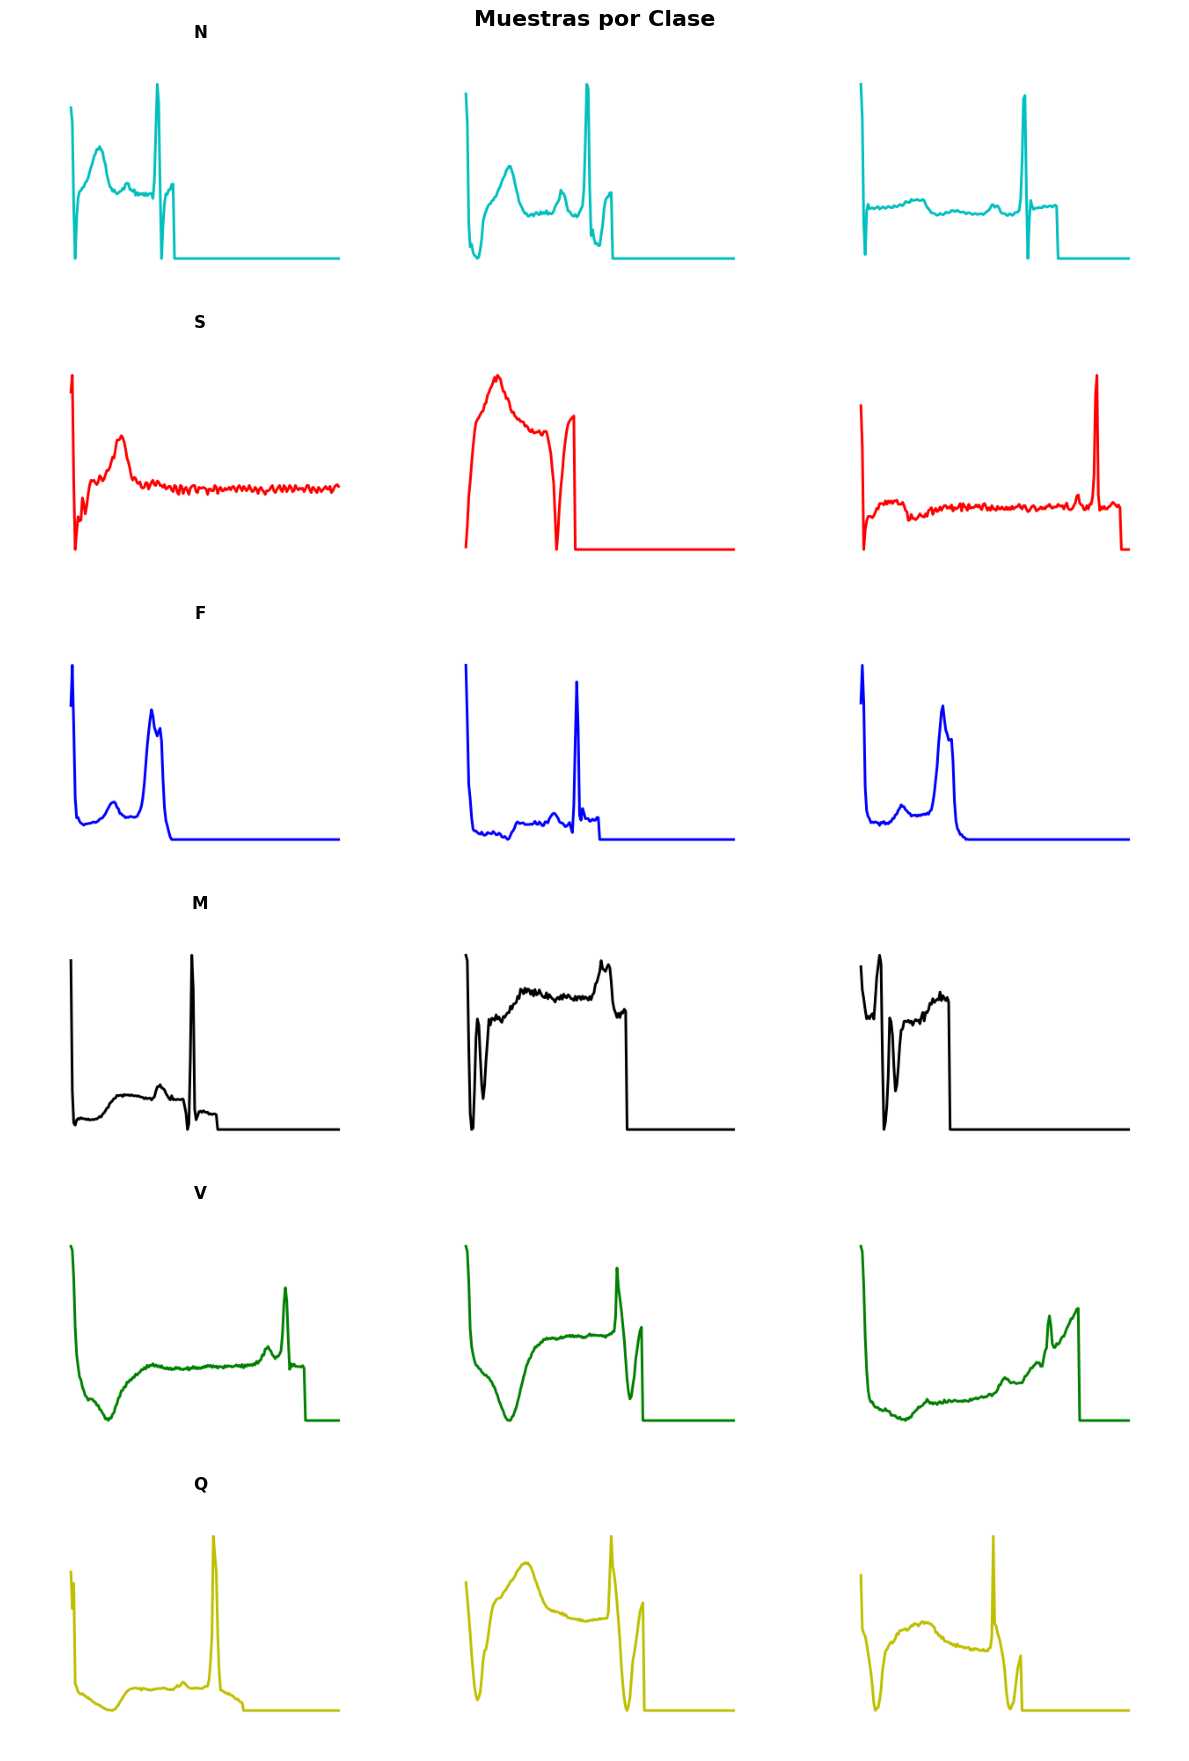


RESUMEN EJECUTIVO
Total de imágenes: 99,199
Número de clases: 6
Resolución promedio: 432 x 288
Tamaño promedio: 7.6 KB
Canales más común: 4

EVALUACIÓN DE CALIDAD:
Dataset muy desbalanceado - considerar técnicas de balanceo
Tamaños de imagen consistentes
No se detectaron problemas críticos

RECOMENDACIONES:
1. Verificar y corregir archivos problemáticos si los hay
2. Considerar normalización de tamaños para entrenamiento
3. Evaluar necesidad de técnicas de balanceo de clases
4. Revisar calidad de imagen antes del preprocesamiento

EDA COMPLETADO EXITOSAMENTE


{'classes':   Clase  Cantidad
 0     N     75709
 3     M      8405
 5     Q      6431
 4     V      5789
 1     S      2223
 2     F       642,
 'properties':      width  height  channels  file_size_kb  aspect_ratio class
 0      432     288         4      8.211914           1.5     N
 1      432     288         4      7.249023           1.5     N
 2      432     288         4      8.088867           1.5     N
 3      432     288         4      6.370117           1.5     N
 4      432     288         4      6.838867           1.5     N
 ..     ...     ...       ...           ...           ...   ...
 995    432     288         4      7.318359           1.5     N
 996    432     288         4      7.812500           1.5     N
 997    432     288         4      6.870117           1.5     N
 998    432     288         4      7.833984           1.5     N
 999    432     288         4      9.291016           1.5     Q
 
 [1000 rows x 6 columns],
 'quality':      brightness   contrast    sha

In [11]:
def generate_final_report(dataset_path):
    """Generar reporte completo del EDA"""
    print("="*60)
    print("REPORTE COMPLETO - DATASET ECG_IMAGE_DATA")
    print("="*60)
    # Ejecutar todos los análisis
    classes, total_images = basic_dataset_info(dataset_path)
    df_classes = analyze_class_distribution(classes)
    df_props = analyze_image_properties(dataset_path)
    df_quality = analyze_ecg_quality(dataset_path)
    issues, size_counts = detect_issues(dataset_path)

    # Visualizaciones
    visualize_image_properties(df_props)
    visualize_quality_metrics(df_quality)
    show_sample_images(dataset_path)

    print("\n" + "="*60)
    print("RESUMEN EJECUTIVO")
    print("="*60)

    print(f"Total de imágenes: {total_images:,}")
    print(f"Número de clases: {len(classes)}")
    print(f"Resolución promedio: {df_props['width'].mean():.0f} x {df_props['height'].mean():.0f}")
    print(f"Tamaño promedio: {df_props['file_size_kb'].mean():.1f} KB")
    print(f"Canales más común: {df_props['channels'].mode().iloc[0]}")

    # Evaluación de calidad del dataset
    print(f"\nEVALUACIÓN DE CALIDAD:")

    # Balance de clases
    max_class = df_classes['Cantidad'].max()
    min_class = df_classes['Cantidad'].min()
    balance_ratio = max_class / min_class if min_class > 0 else float('inf')

    if balance_ratio <= 2:
        print("Dataset bien balanceado")
    elif balance_ratio <= 5:
        print("Dataset moderadamente desbalanceado")
    else:
        print("Dataset muy desbalanceado - considerar técnicas de balanceo")

    # Consistencia de tamaños
    size_variety = len(size_counts)
    if size_variety <= 3:
        print("Tamaños de imagen consistentes")
    else:
        print("Gran variedad en tamaños de imagen - considerar normalización")

    # Problemas detectados
    total_issues = sum(len(v) for v in issues.values())
    if total_issues == 0:
        print("No se detectaron problemas críticos")
    else:
        print(f"{total_issues} problemas detectados - revisar archivos problemáticos")

    print(f"\nRECOMENDACIONES:")
    print("1. Verificar y corregir archivos problemáticos si los hay")
    print("2. Considerar normalización de tamaños para entrenamiento")
    print("3. Evaluar necesidad de técnicas de balanceo de clases")
    print("4. Revisar calidad de imagen antes del preprocesamiento")

    print("\nEDA COMPLETADO EXITOSAMENTE")

    return {
        'classes': df_classes,
        'properties': df_props,
        'quality': df_quality,
        'issues': issues
    }

generate_final_report(dataset_path)